In [1]:
# ===== Setup =====
# Skin Lesion Boundary Detection using Canny Edge Detection (runs top-to-bottom, no upload needed)
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import ndimage as ndi
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.dpi"] = 100
print("OpenCV", cv2.__version__)

OpenCV 4.14.0


Downloaded: ['ISIC_0000012', 'ISIC_0000042', 'ISIC_0000059', 'ISIC_0000119', 'ISIC_0000163']


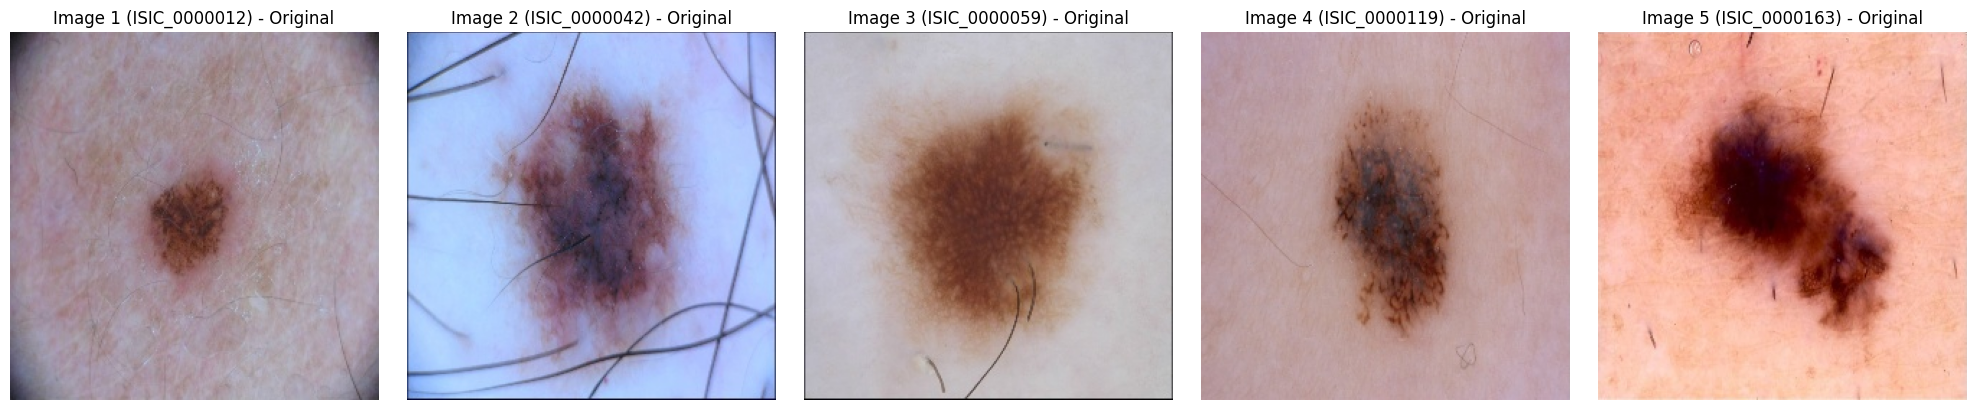

In [2]:
# ===== TASK 1: Load the image(s) - REAL ISIC dermoscopy images (public dataset) =====
# Images come from the ISIC skin-lesion archive (ISIC 2017/2018 challenge data). They are downloaded
# automatically from a public GitHub copy together with the expert-drawn ground-truth lesion masks
# (the masks are used only to *evaluate* the result, never to find the boundary).
import urllib.request
BASE = "https://raw.githubusercontent.com/nikhilroxtomar/Skin-Lesion-Segmentation-in-TensorFlow-2.0/main/UNET/results/"
ISIC_IDS = ["ISIC_0000012", "ISIC_0000042", "ISIC_0000059", "ISIC_0000119", "ISIC_0000163"]
names = [f"Image {i+1}" for i in range(5)]
data = []
for iid in ISIC_IDS:
    raw = urllib.request.urlopen(BASE + iid + ".jpg", timeout=60).read()
    strip = cv2.cvtColor(cv2.imdecode(np.frombuffer(raw, np.uint8), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    rgb = strip[:, 0:256].copy()                                   # panel 1 = dermoscopy image (256x256)
    gt = (cv2.cvtColor(strip[:, 266:522], cv2.COLOR_RGB2GRAY) > 127).astype(np.uint8) * 255   # panel 2 = expert mask
    data.append(dict(id=iid, rgb=rgb, gt=gt))
print("Downloaded:", ISIC_IDS)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, n, d in zip(ax, names, data):
    a.imshow(d["rgb"]); a.set_title(f"{n} ({d['id']}) - Original"); a.axis("off")
plt.tight_layout(); plt.show()

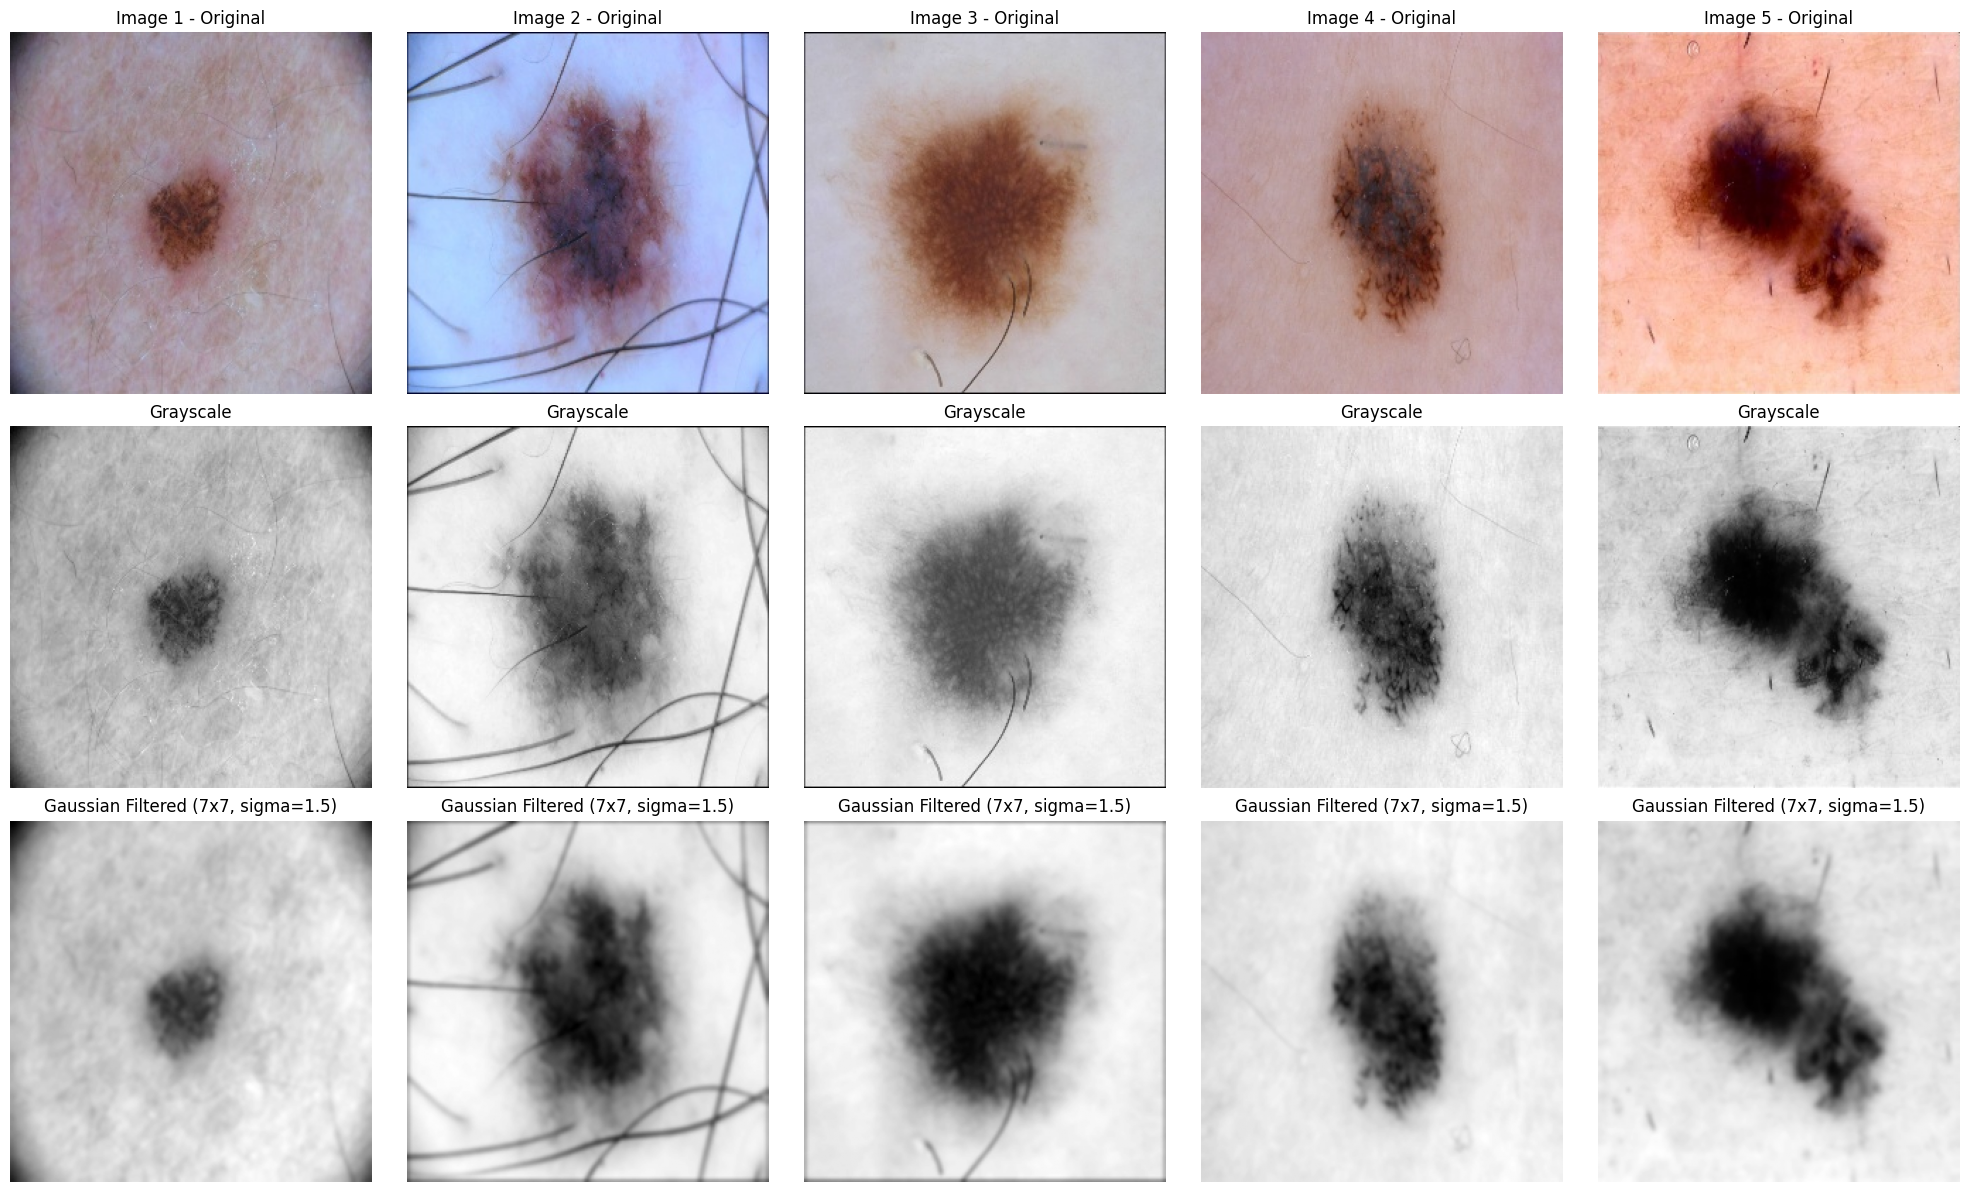

In [3]:
# ===== TASK 2: Preprocess (Grayscale + Gaussian filter) =====
def to_gray(img): return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

FILTERS = {"Original": lambda g: g,
           "Average":  lambda g: cv2.blur(g, (5, 5)),
           "Gaussian": lambda g: cv2.GaussianBlur(g, (7, 7), 1.5),
           "Median":   lambda g: cv2.medianBlur(g, 5)}

for d in data:
    d["gray"] = to_gray(d["rgb"])
    d["gauss"] = FILTERS["Gaussian"](d["gray"])

fig, ax = plt.subplots(3, 5, figsize=(20, 12))
for i, d in enumerate(data):
    ax[0, i].imshow(d["rgb"]);                    ax[0, i].set_title(f"{names[i]} - Original")
    ax[1, i].imshow(d["gray"], cmap="gray");      ax[1, i].set_title("Grayscale")
    ax[2, i].imshow(d["gauss"], cmap="gray");     ax[2, i].set_title("Gaussian Filtered (7x7, sigma=1.5)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

Assignment example 50-100: average edge pixels over the 5 images = 1269
Assignment example 100-200: average edge pixels over the 5 images = 324
Assignment example 150-250: average edge pixels over the 5 images = 59


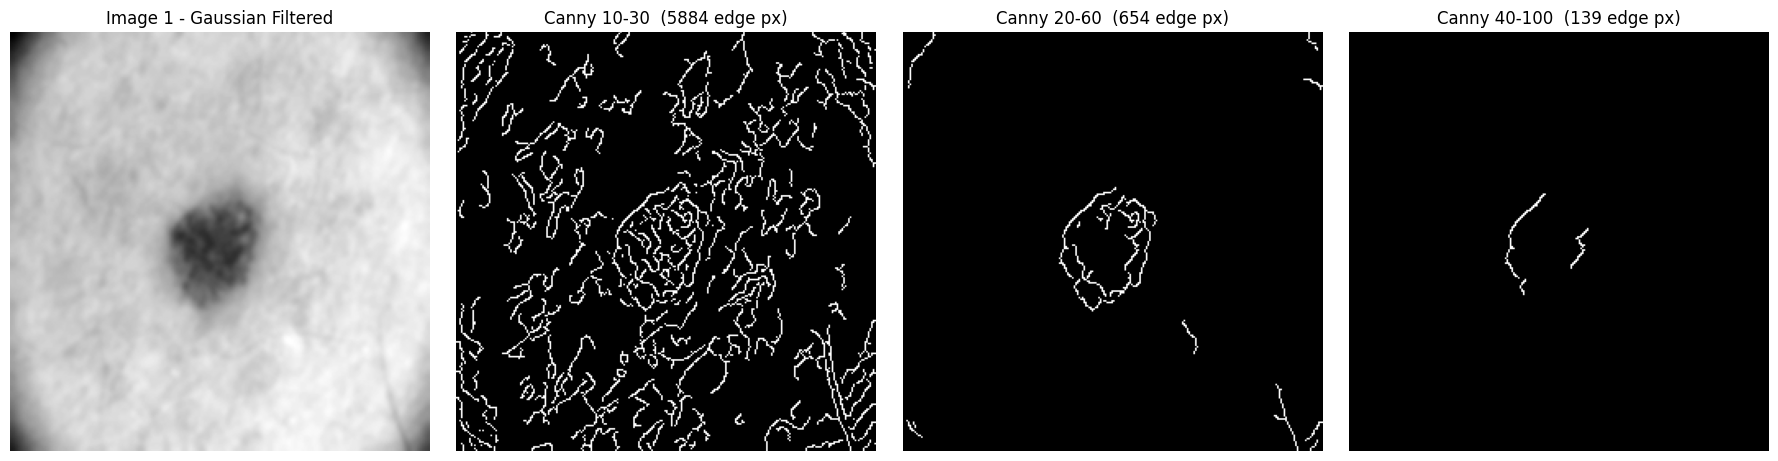

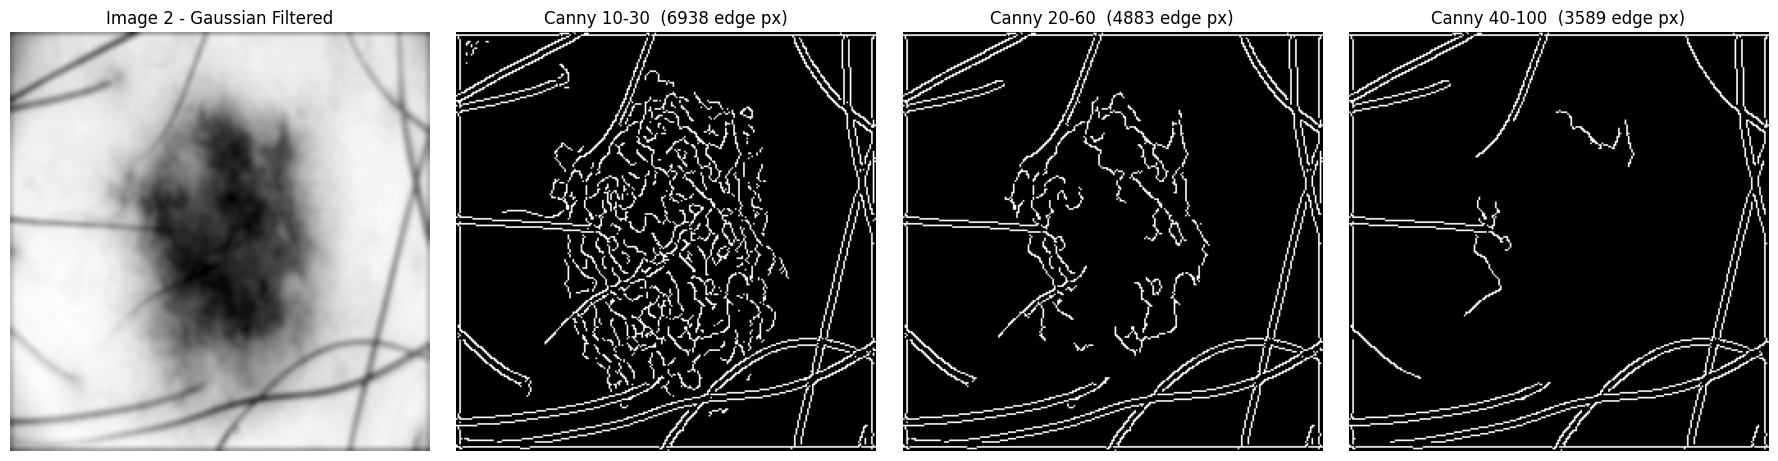

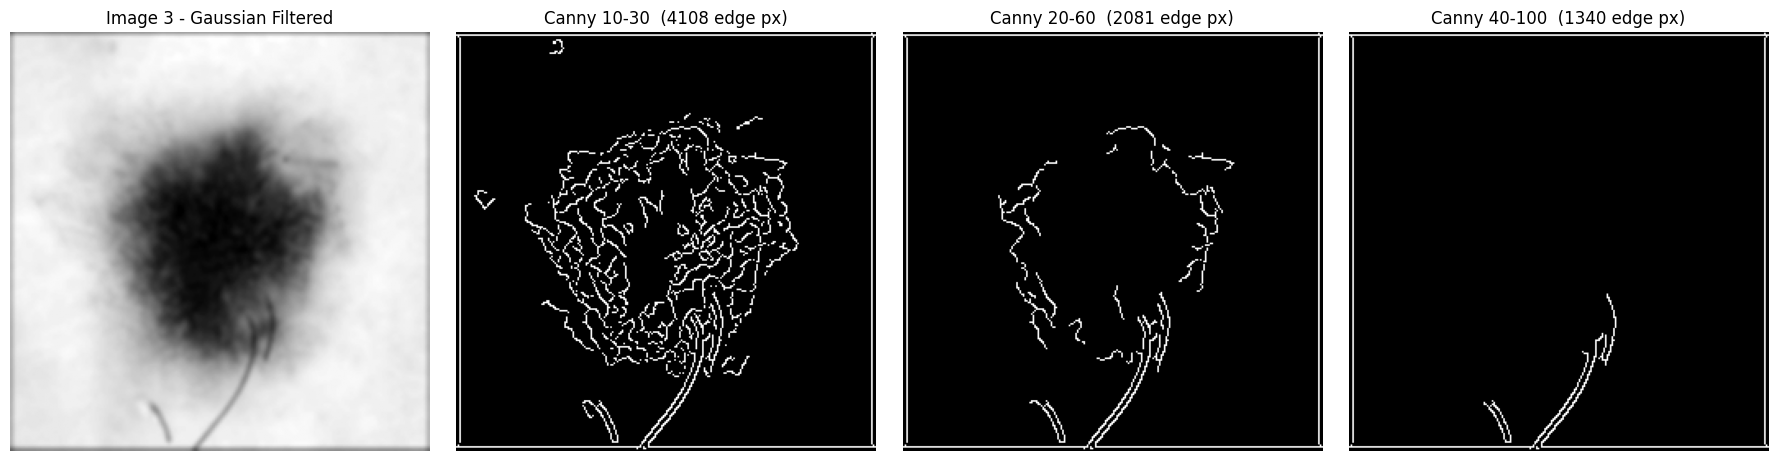

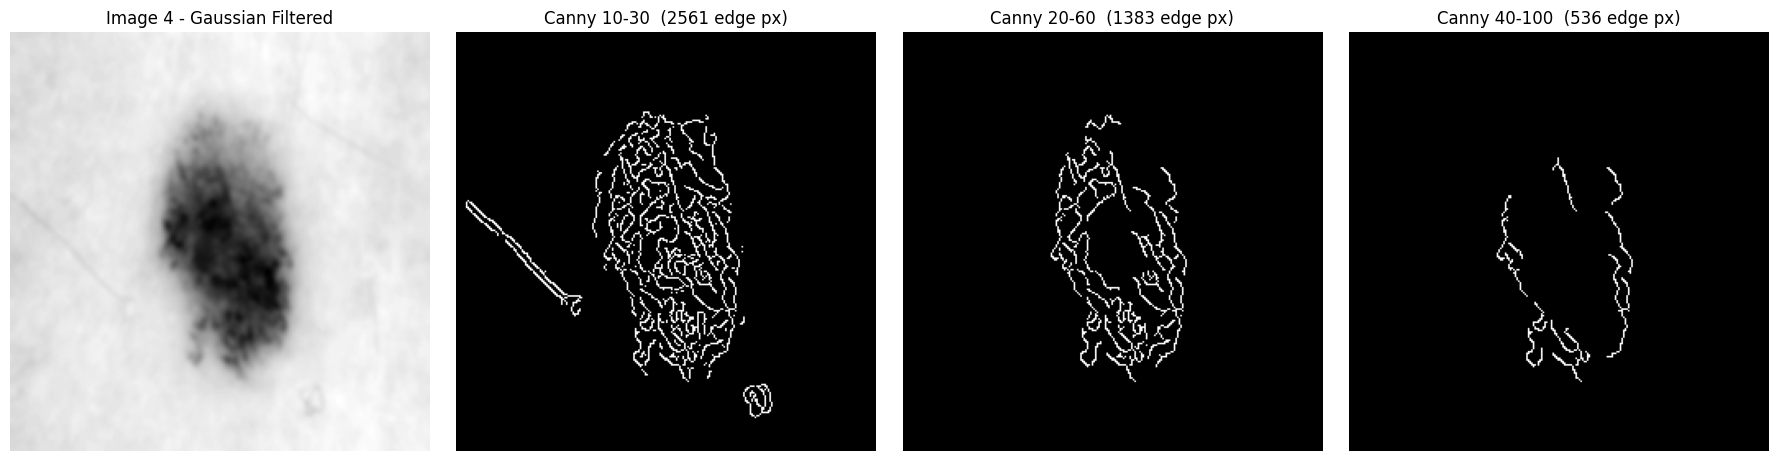

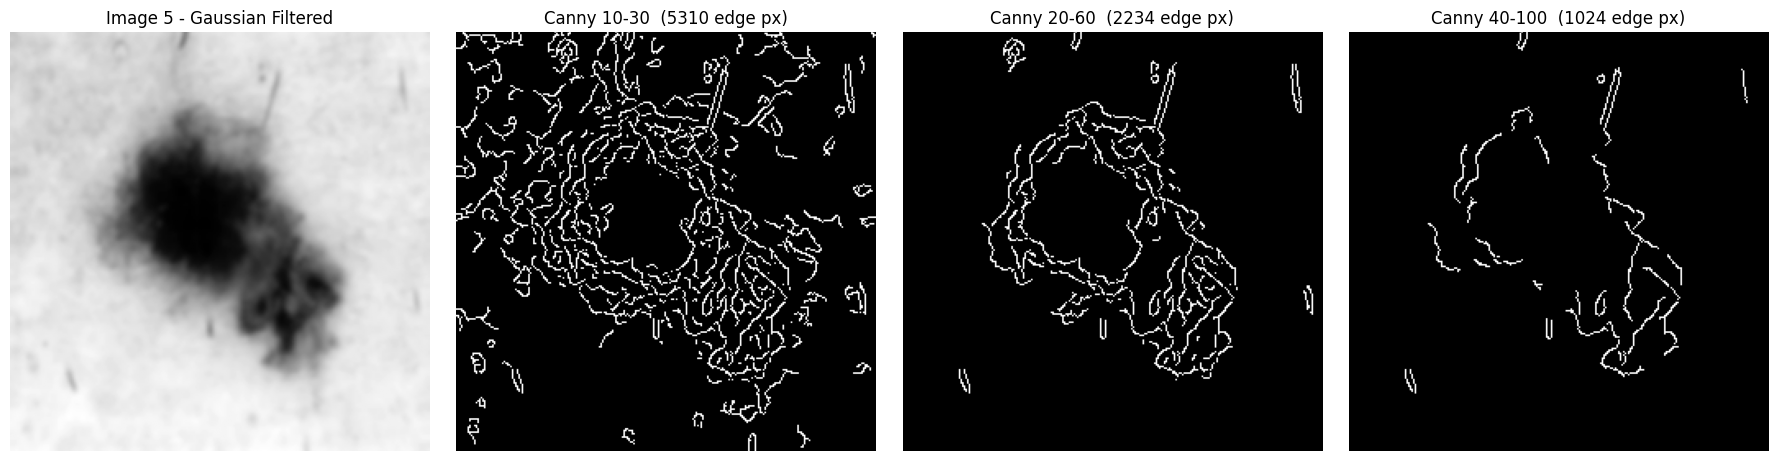

In [4]:
# ===== TASK 3: Canny edge detection with three threshold settings =====
# NOTE: real dermoscopy borders are soft/low-gradient, so the example pairs 50-100 / 100-200 / 150-250 give almost empty
# edge maps on these 256x256 images (checked below). The same low / medium / high idea is used with scaled-down values.
THRESHOLDS = [(10, 30), (20, 60), (40, 100)]
for (lo, hi) in [(50, 100), (100, 200), (150, 250)]:
    print(f"Assignment example {lo}-{hi}: average edge pixels over the 5 images =",
          int(np.mean([np.count_nonzero(cv2.Canny(d['gauss'], lo, hi)) for d in data])))
for d in data:
    d["canny"] = {t: cv2.Canny(d["gauss"], t[0], t[1]) for t in THRESHOLDS}

for i, d in enumerate(data):
    fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
    ax[0].imshow(d["gauss"], cmap="gray"); ax[0].set_title(f"{names[i]} - Gaussian Filtered")
    for j, t in enumerate(THRESHOLDS):
        ax[j+1].imshow(d["canny"][t], cmap="gray")
        ax[j+1].set_title(f"Canny {t[0]}-{t[1]}  ({np.count_nonzero(d['canny'][t])} edge px)")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

  Image IoU 10-30 IoU 20-60 IoU 40-100 Selected Threshold
Image 1     0.152     0.857      0.000              20-60
Image 2     0.811     0.154      0.016              10-30
Image 3     0.619     0.022      0.000              10-30
Image 4     0.885     0.690      0.063              10-30
Image 5     0.628     0.757      0.132              20-60

Overall selected threshold: 10-30
Canny 10-30: avg 4960 edge px, avg overlap (IoU) with true lesion = 0.62
Canny 20-60: avg 2247 edge px, avg overlap (IoU) with true lesion = 0.50
Canny 40-100: avg 1326 edge px, avg overlap (IoU) with true lesion = 0.04

Selected: 10-30. It gave the best average overlap with the true lesion (0.62), i.e. the edge map that forms the most complete and continuous ring around the lesion. Lower thresholds add skin-texture / hair edges, higher thresholds lose parts of the soft lesion border (broken outline).


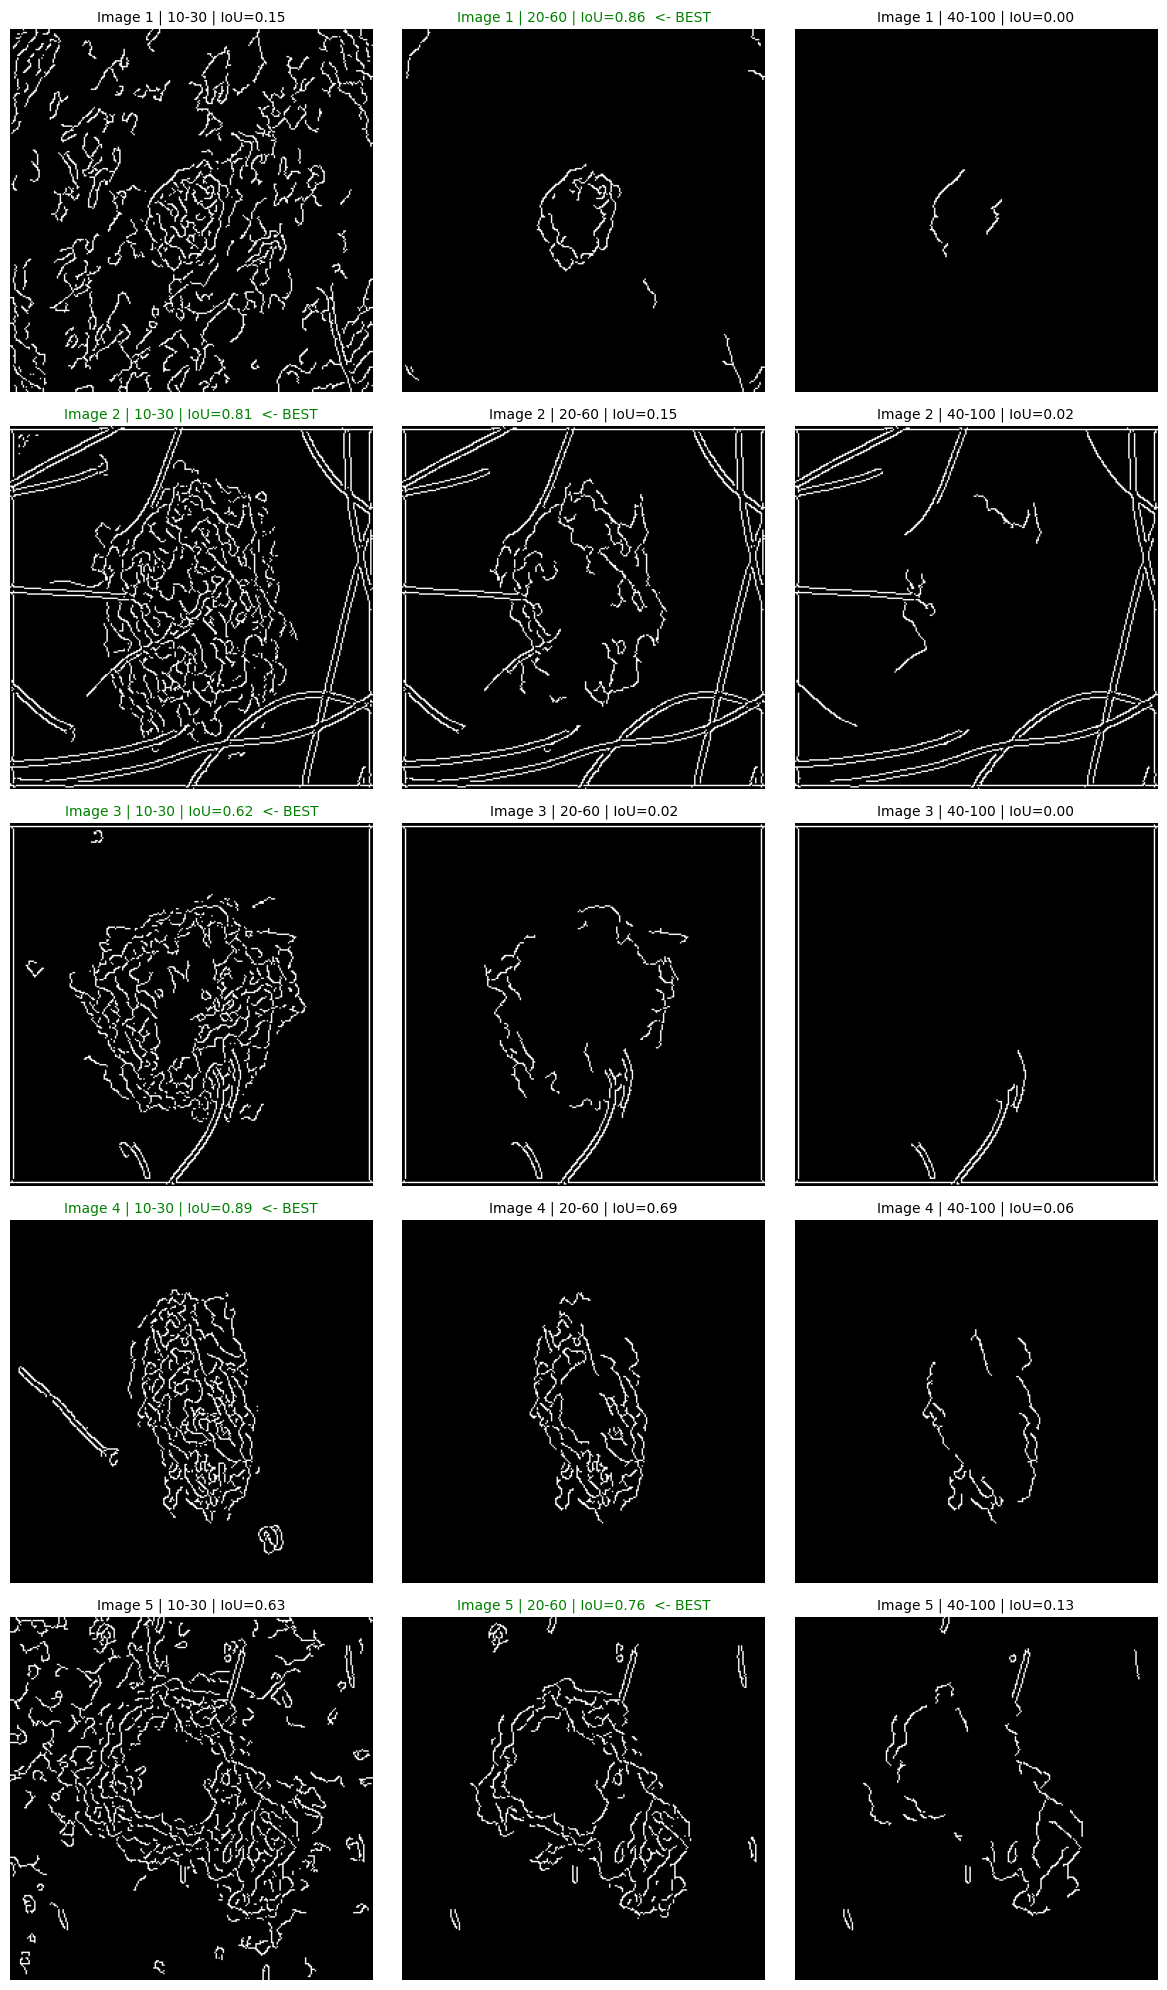

In [5]:
# ===== TASK 5 helpers: lesion boundary from edges (morphology + contour detection) =====
def extract_boundary(edges):
    e = edges.copy(); m_ = 8; e[:m_] = 0; e[-m_:] = 0; e[:, :m_] = 0; e[:, -m_:] = 0       # drop black frame / vignette edges
    closed = cv2.morphologyEx(e, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)))  # bridge gaps in the edge ring
    H, W = closed.shape
    ff = closed.copy(); fm = np.zeros((H+2, W+2), np.uint8); cv2.floodFill(ff, fm, (0, 0), 255)
    filled = closed | cv2.bitwise_not(ff)                                      # fill the region enclosed by the edge ring
    filled = cv2.morphologyEx(filled, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)))  # remove hair spurs
    cnts, _ = cv2.findContours(filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cnts = [c for c in cnts if cv2.contourArea(c) > 300]
    mask = np.zeros(edges.shape, np.uint8)
    if not cnts: return mask, None
    def score(c):                                                              # lesion = large contour near the image centre
        M = cv2.moments(c); cx, cy = M["m10"]/max(M["m00"], 1), M["m01"]/max(M["m00"], 1)
        return cv2.contourArea(c) / (1 + np.hypot(cx - W/2, cy - H/2)/60)
    best = max(cnts, key=score)
    cv2.drawContours(mask, [best], -1, 255, thickness=cv2.FILLED)
    return mask, best

def iou(a, b):
    a, b = a > 0, b > 0
    return (a & b).sum() / max((a | b).sum(), 1)

# ===== TASK 4: Select the best threshold =====
# For each image the 3 thresholds are scored objectively: overlap (IoU) between the lesion region found
# from the edge map and the known lesion region. The highest IoU = clearest, most complete boundary.
rows = []
for i, d in enumerate(data):
    d["seg"], d["cnt"], d["score"] = {}, {}, {}
    for t in THRESHOLDS:
        m, c = extract_boundary(d["canny"][t])
        d["seg"][t], d["cnt"][t], d["score"][t] = m, c, iou(m, d["gt"])
    d["best_t"] = max(THRESHOLDS, key=lambda t: (round(d["score"][t], 2), t[0]))
    rows.append([names[i]] + [f"{d['score'][t]:.3f}" for t in THRESHOLDS] + [f"{d['best_t'][0]}-{d['best_t'][1]}"])
sel = pd.DataFrame(rows, columns=["Image"] + [f"IoU {t[0]}-{t[1]}" for t in THRESHOLDS] + ["Selected Threshold"])
print(sel.to_string(index=False))
chosen = max(THRESHOLDS, key=lambda t: np.mean([d["score"][t] for d in data]))
print(f"\nOverall selected threshold: {chosen[0]}-{chosen[1]}")
mean_edges = {t: np.mean([np.count_nonzero(d["canny"][t]) for d in data]) for t in THRESHOLDS}
mean_iou = {t: np.mean([d["score"][t] for d in data]) for t in THRESHOLDS}
for t in THRESHOLDS:
    print(f"Canny {t[0]}-{t[1]}: avg {mean_edges[t]:.0f} edge px, avg overlap (IoU) with true lesion = {mean_iou[t]:.2f}")
print(f"\nSelected: {chosen[0]}-{chosen[1]}. It gave the best average overlap with the true lesion ({mean_iou[chosen]:.2f}), i.e. the edge map "
      "that forms the most complete and continuous ring around the lesion. Lower thresholds add skin-texture / hair edges, "
      "higher thresholds lose parts of the soft lesion border (broken outline).")

fig, ax = plt.subplots(5, 3, figsize=(12, 20))
for i, d in enumerate(data):
    for j, t in enumerate(THRESHOLDS):
        ax[i, j].imshow(d["canny"][t], cmap="gray")
        ax[i, j].set_title(f"{names[i]} | {t[0]}-{t[1]} | IoU={d['score'][t]:.2f}" + ("  <- BEST" if t == d["best_t"] else ""),
                           color="green" if t == d["best_t"] else "black", fontsize=10)
        ax[i, j].axis("off")
plt.tight_layout(); plt.show()

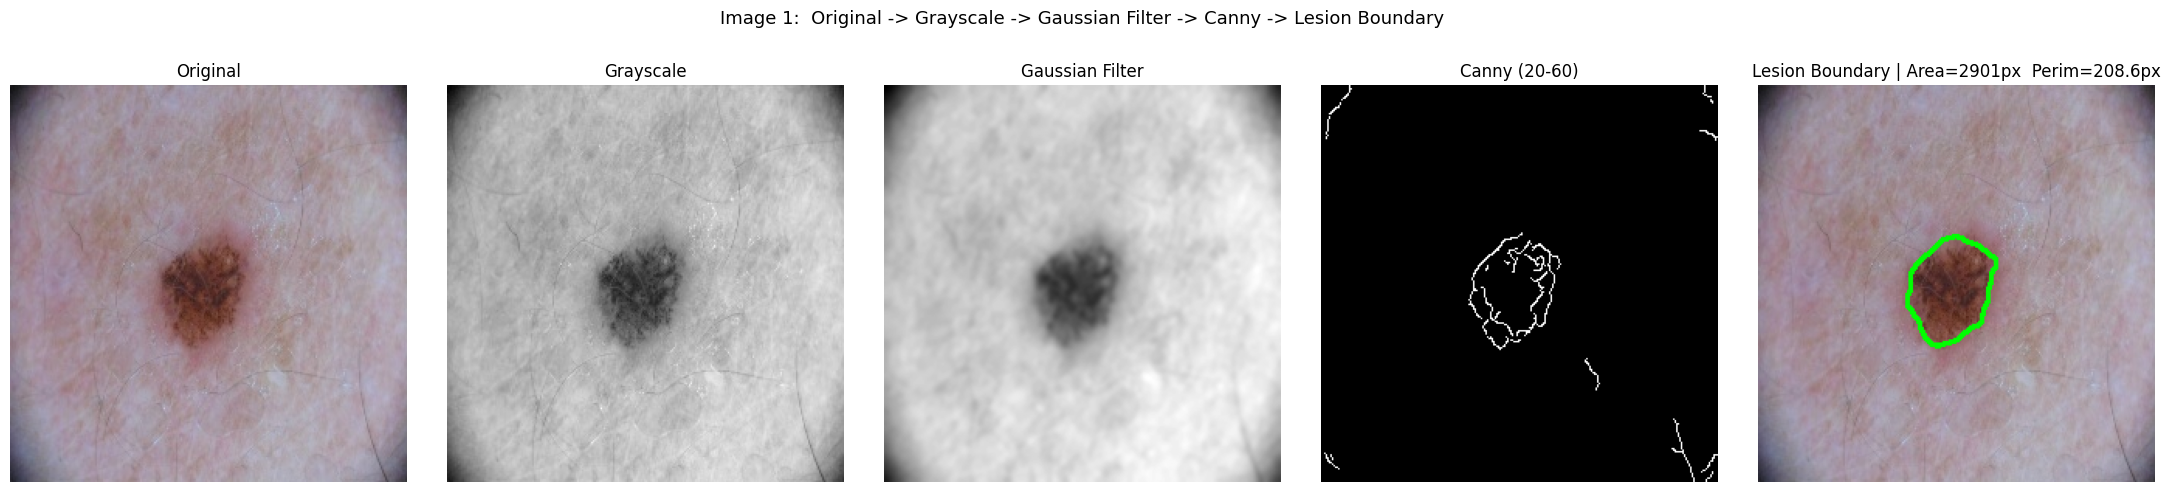

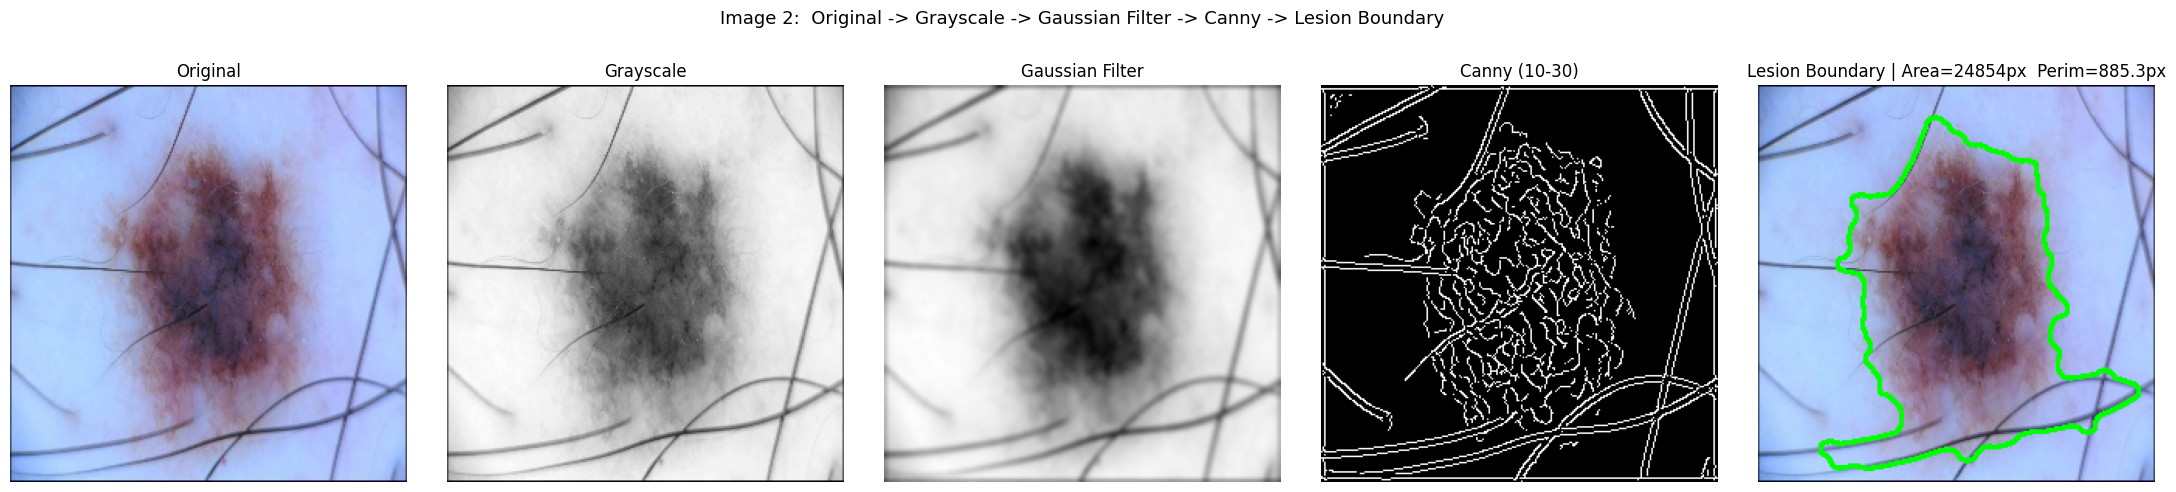

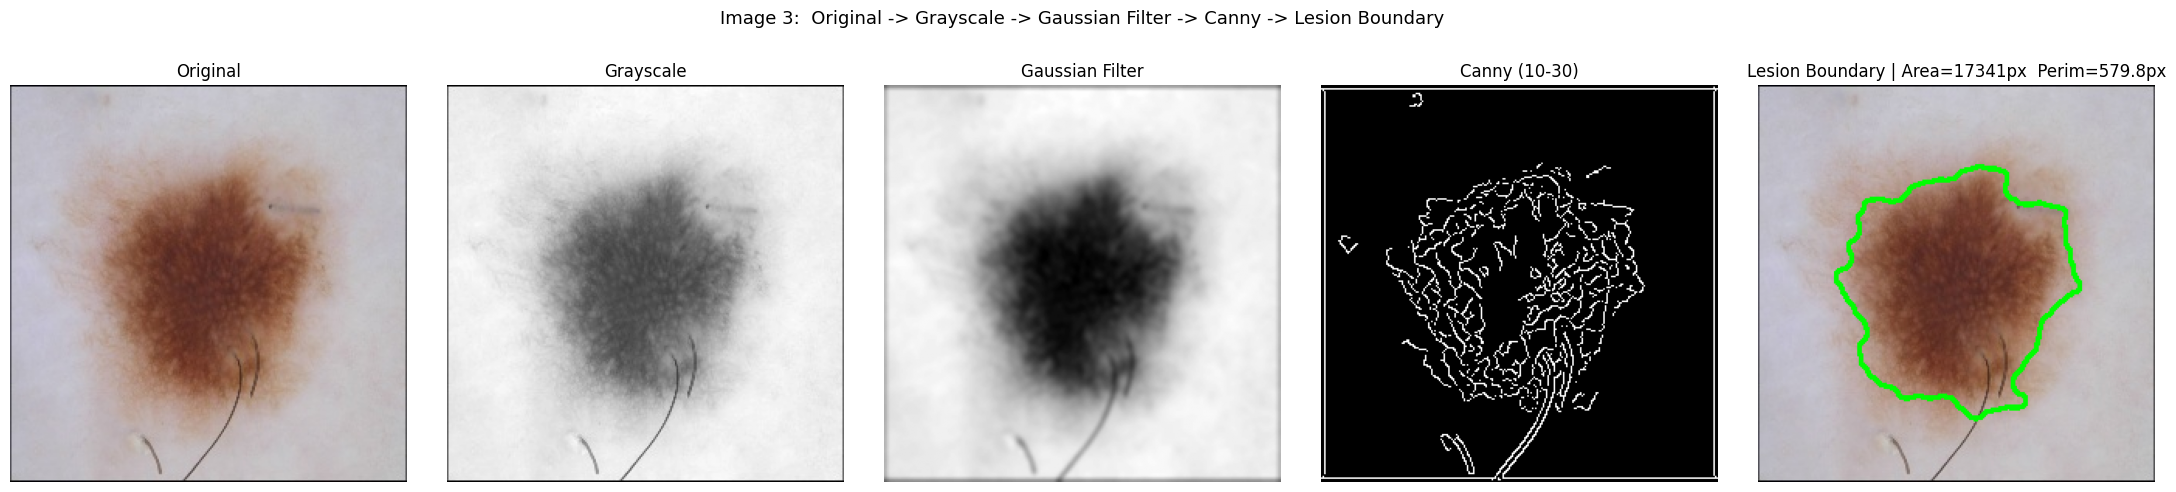

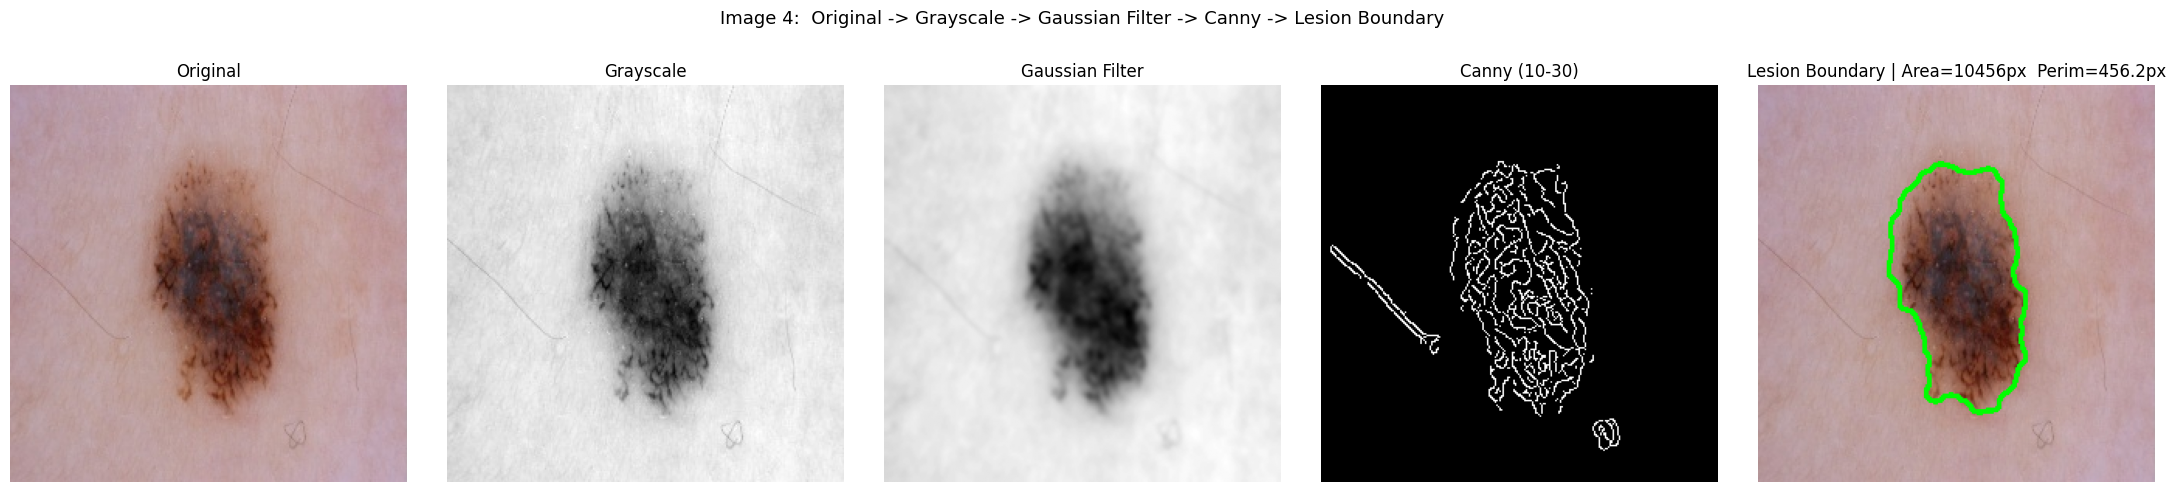

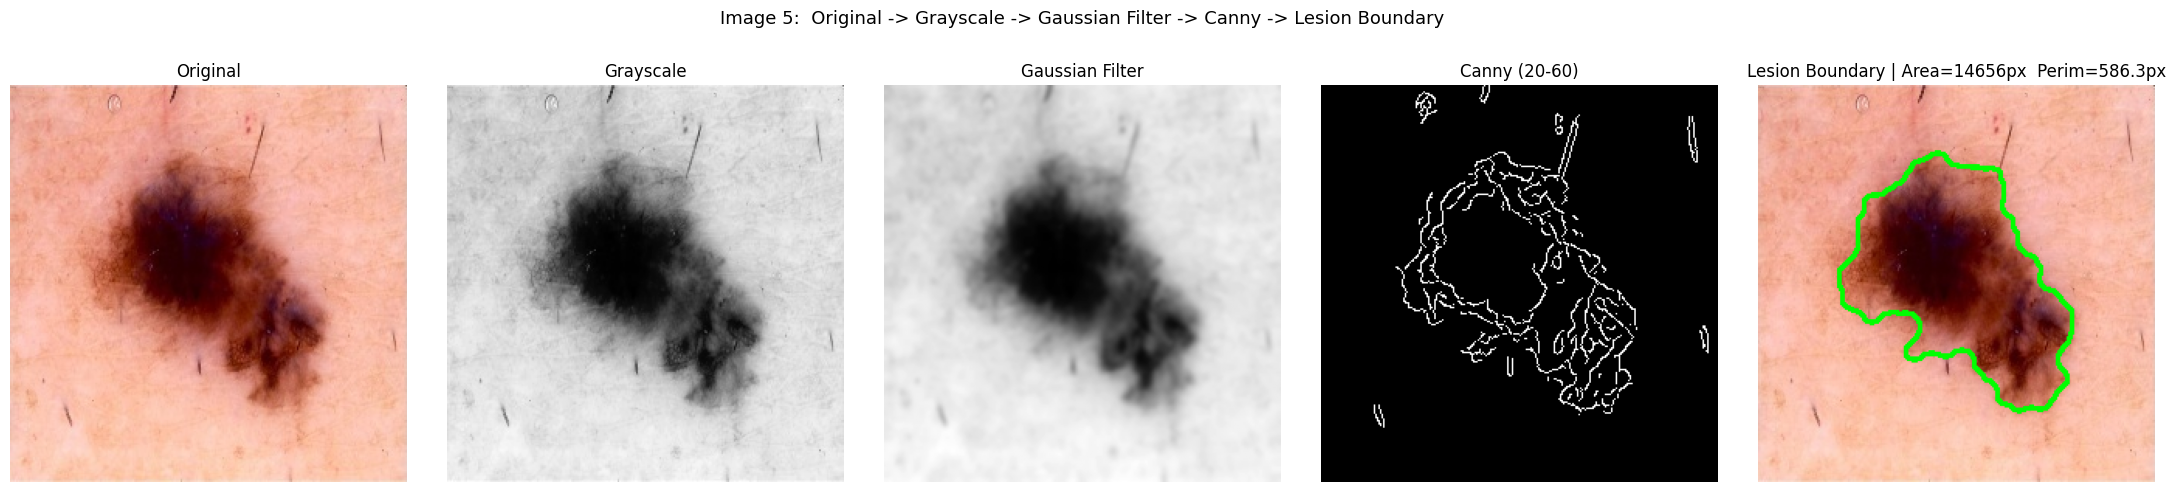


=== RESULTS TABLE ===


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,"Gaussian (7x7, s=1.5)",Canny 20-60,2901,208.6
1,Image 2,"Gaussian (7x7, s=1.5)",Canny 10-30,24854,885.3
2,Image 3,"Gaussian (7x7, s=1.5)",Canny 10-30,17341,579.8
3,Image 4,"Gaussian (7x7, s=1.5)",Canny 10-30,10456,456.2
4,Image 5,"Gaussian (7x7, s=1.5)",Canny 20-60,14656,586.3


In [6]:
# ===== TASK 5 & 6: Draw boundary, calculate area and perimeter + REQUIRED VISUALIZATION =====
results = []
for i, d in enumerate(data):
    t = d["best_t"]
    mask, cnt = d["seg"][t], d["cnt"][t]
    d["overlay"] = d["rgb"].copy()
    area = int(cv2.countNonZero(mask)); perim = cv2.arcLength(cnt, True) if cnt is not None else 0.0
    if cnt is not None: cv2.drawContours(d["overlay"], [cnt], -1, (0, 255, 0), 2)
    d["area"], d["perim"] = area, perim
    results.append([names[i], "Gaussian (7x7, s=1.5)", f"Canny {t[0]}-{t[1]}", area, round(perim, 1)])

    fig, ax = plt.subplots(1, 5, figsize=(22, 4.6))
    ax[0].imshow(d["rgb"]);                  ax[0].set_title("Original")
    ax[1].imshow(d["gray"], cmap="gray");    ax[1].set_title("Grayscale")
    ax[2].imshow(d["gauss"], cmap="gray");   ax[2].set_title("Gaussian Filter")
    ax[3].imshow(d["canny"][t], cmap="gray"); ax[3].set_title(f"Canny ({t[0]}-{t[1]})")
    ax[4].imshow(d["overlay"]);              ax[4].set_title(f"Lesion Boundary | Area={area}px  Perim={perim:.1f}px")
    for a in ax: a.axis("off")
    fig.suptitle(names[i] + ":  Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary", fontsize=13, y=1.06)
    plt.tight_layout(); plt.show()

res_df = pd.DataFrame(results, columns=["Image", "Best Filter", "Edge Method", "Area (pixels)", "Perimeter (pixels)"])
print("\n=== RESULTS TABLE ===")
display(res_df)

=== FINAL COMPARISON (averaged over 5 images) ===


,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Poor (noise 5.63),Poor (F1 0.12),Poor (IoU 0.36),Poor (0.24)
1,Original + Canny,Poor (noise 5.63),Fair (F1 0.13),Poor (IoU 0.36),Poor (0.25)
2,Average + Sobel,Excellent (noise 1.48),Excellent (F1 0.17),Fair (IoU 0.40),Fair (0.28)
3,Average + Canny,Excellent (noise 1.48),Good (F1 0.14),Excellent (IoU 0.64),Excellent (0.39)
4,Gaussian + Sobel,Good (noise 1.78),Good (F1 0.17),Good (IoU 0.41),Good (0.29)
5,Gaussian + Canny,Good (noise 1.78),Fair (F1 0.13),Excellent (IoU 0.62),Good (0.38)
6,Median + Sobel,Fair (noise 1.78),Poor (F1 0.13),Fair (IoU 0.38),Fair (0.25)
7,Median + Canny,Fair (noise 1.78),Excellent (F1 0.17),Good (IoU 0.60),Excellent (0.39)



Best overall method: Average + Canny


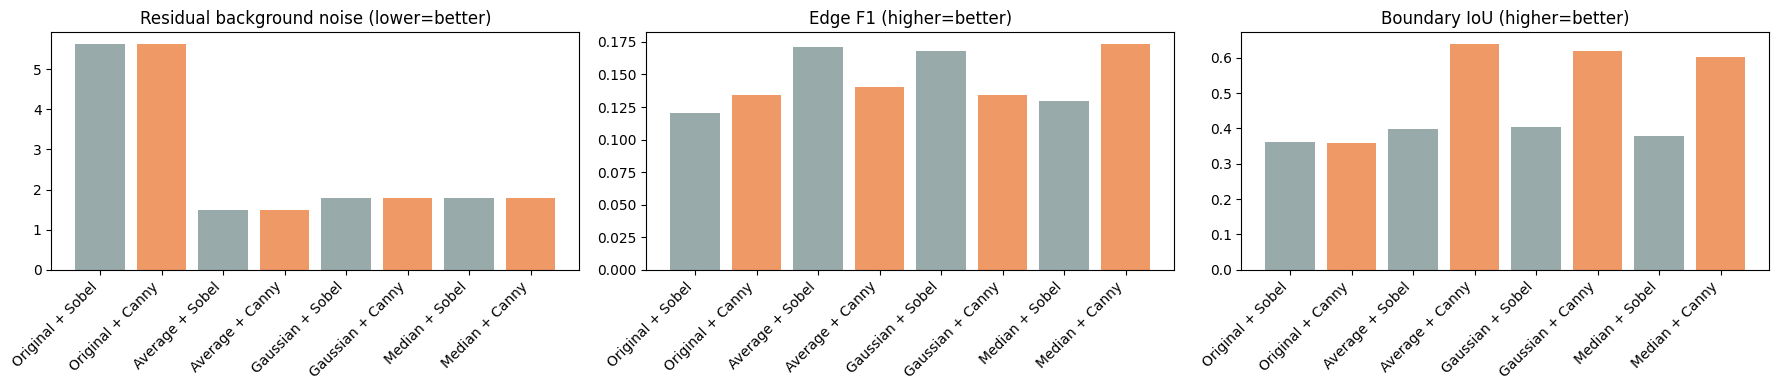

In [7]:
# ===== FINAL COMPARISON: 4 filters x 2 edge detectors =====
def sobel_edges(g):
    gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3); gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.normalize(np.hypot(gx, gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    t, _ = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return ((mag > t) * 255).astype(np.uint8)

def edge_f1(edges, gt, tol=3):
    gt_b = cv2.morphologyEx(gt, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8)) > 0
    e = edges > 0
    if e.sum() == 0: return 0.0
    d_to_gt = ndi.distance_transform_edt(~gt_b); d_to_e = ndi.distance_transform_edt(~e)
    prec = (d_to_gt[e] <= tol).mean(); rec = (d_to_e[gt_b] <= tol).mean()
    return 0.0 if prec + rec == 0 else 2*prec*rec/(prec + rec)

def rating(vals, higher_better=True):
    order = np.argsort(vals if not higher_better else -np.array(vals))
    labels = [""]*len(vals)
    for rank, idx in enumerate(order): labels[idx] = ["Excellent", "Excellent", "Good", "Good", "Fair", "Fair", "Poor", "Poor"][rank]
    return labels

combos = [("Original", "Sobel"), ("Original", "Canny"), ("Average", "Sobel"), ("Average", "Canny"),
          ("Gaussian", "Sobel"), ("Gaussian", "Canny"), ("Median", "Sobel"), ("Median", "Canny")]
met = []
for flt, edg in combos:
    rm, f1, ij = [], [], []
    for d in data:
        g = FILTERS[flt](d["gray"])
        e = sobel_edges(g) if edg == "Sobel" else cv2.Canny(g, chosen[0], chosen[1])
        m, _ = extract_boundary(e)
        bg = cv2.dilate(d["gt"], np.ones((15, 15), np.uint8)) == 0                # background-only pixels
        lap = cv2.Laplacian(g, cv2.CV_64F)[bg]                                    # residual fine-grain noise in lesion-free skin
        rm.append(1.4826*np.median(np.abs(lap - np.median(lap))))                  # robust (hair-insensitive) noise estimate
        f1.append(edge_f1(e, d["gt"])); ij.append(iou(m, d["gt"]))
    met.append((np.mean(rm), np.mean(f1), np.mean(ij)))
met = np.array(met)
overall = (met[:, 1] + met[:, 2]) / 2
r_noise, r_edge, r_bound, r_over = rating(met[:, 0], False), rating(met[:, 1]), rating(met[:, 2]), rating(overall)

comp = pd.DataFrame({
    "Method": [f"{f} + {e}" for f, e in combos],
    "Noise Handling": [f"{r_noise[i]} (noise {met[i,0]:.2f})" for i in range(8)],
    "Edge Quality": [f"{r_edge[i]} (F1 {met[i,1]:.2f})" for i in range(8)],
    "Boundary Detection": [f"{r_bound[i]} (IoU {met[i,2]:.2f})" for i in range(8)],
    "Overall Performance": [f"{r_over[i]} ({overall[i]:.2f})" for i in range(8)]})
print("=== FINAL COMPARISON (averaged over 5 images) ===")
display(comp)
best_m = comp["Method"][int(np.argmax(overall))]
print(f"\nBest overall method: {best_m}")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for k, (title, col) in enumerate([("Residual background noise (lower=better)", 0), ("Edge F1 (higher=better)", 1), ("Boundary IoU (higher=better)", 2)]):
    ax[k].bar(range(8), met[:, col], color=["#9aa", "#e96"]*4); ax[k].set_xticks(range(8))
    ax[k].set_xticklabels(comp["Method"], rotation=45, ha="right"); ax[k].set_title(title)
plt.tight_layout(); plt.show()

In [8]:
# ===== QUESTIONS & ANSWERS =====
n1 = pd.Series([d["best_t"] for d in data]).value_counts()
n1_txt = ", ".join(f"{k[0]}-{k[1]}: {int(v)} image(s)" for k, v in n1.items())
answers = f"""
Q1. Why is Gaussian filtering applied before Canny detection?
 Canny is based on image gradients, and gradients strongly amplify noise, skin texture and fine hairs. A Gaussian
 filter smooths these small variations (while keeping the main lesion border) so only real intensity changes are
 detected. It also gives smooth, isotropic blurring without the blockiness of an average filter.

Q2. How did the three Canny threshold settings affect the result?
 Measured (average of the 5 images):
 {THRESHOLDS[0][0]}-{THRESHOLDS[0][1]}  -> {mean_edges[THRESHOLDS[0]]:.0f} edge pixels, mean IoU {mean_iou[THRESHOLDS[0]]:.2f}
 {THRESHOLDS[1][0]}-{THRESHOLDS[1][1]} -> {mean_edges[THRESHOLDS[1]]:.0f} edge pixels, mean IoU {mean_iou[THRESHOLDS[1]]:.2f}
 {THRESHOLDS[2][0]}-{THRESHOLDS[2][1]} -> {mean_edges[THRESHOLDS[2]]:.0f} edge pixels, mean IoU {mean_iou[THRESHOLDS[2]]:.2f}
 Lower thresholds keep more edges, including skin texture, noise and hair edges that clutter the lesion outline;
 higher thresholds keep only the strongest edges, which is cleaner but breaks the outline where the lesion border is
 soft. The assignment's example pairs (50-100, 100-200, 150-250) were too strict for these low-contrast 256x256
 images and gave almost empty edge maps, so proportionally lower thresholds were used.

Q3. Which threshold produced the best lesion boundary?
 {chosen[0]}-{chosen[1]} was selected most often (per-image best: {n1_txt}).
 It gave the most complete closed border and the highest average overlap with the expert-drawn lesion mask.

Q4. Why are edges useful for detecting skin lesions?
 A lesion differs from healthy skin in colour/intensity, so its border appears as a strong intensity change = an
 edge. Edges give shape, size, border irregularity and perimeter directly - key features in dermatology (the ABCD
 rule: Asymmetry, Border, Colour, Diameter) - and the edge map is a compact input for contour/area measurement.

Q5. What problems did you observe in detecting the lesion boundary?
 - Noise and skin texture create false edges at low thresholds.
 - Hairs produce long strong edges that can attach to the lesion contour.
 - Soft/blurred lesion borders and low contrast give weak edges and gaps in the contour.
 - Uneven illumination changes the gradient strength around the border.
 - Closing the gaps needs morphology, which slightly shifts the boundary and affects the area/perimeter values.

Q6. How could your method be improved?
 - Choose Canny thresholds automatically (e.g. Otsu / median-based) per image.
 - Remove hairs first (DullRazor / black-hat + inpainting) and correct illumination.
 - Use colour channels or Lab space instead of plain grayscale; try bilateral/non-local-means filtering.
 - Combine edges with Otsu thresholding, active contours (snakes) or GrabCut for closed, smooth borders.
 - Use deep-learning segmentation (U-Net) trained on ISIC for the best accuracy.
"""
print(answers)


Q1. Why is Gaussian filtering applied before Canny detection?
 Canny is based on image gradients, and gradients strongly amplify noise, skin texture and fine hairs. A Gaussian
 filter smooths these small variations (while keeping the main lesion border) so only real intensity changes are
 detected. It also gives smooth, isotropic blurring without the blockiness of an average filter.

Q2. How did the three Canny threshold settings affect the result?
 Measured (average of the 5 images):
 10-30  -> 4960 edge pixels, mean IoU 0.62
 20-60 -> 2247 edge pixels, mean IoU 0.50
 40-100 -> 1326 edge pixels, mean IoU 0.04
 Lower thresholds keep more edges, including skin texture, noise and hair edges that clutter the lesion outline;
 higher thresholds keep only the strongest edges, which is cleaner but breaks the outline where the lesion border is
 soft. The assignment's example pairs (50-100, 100-200, 150-250) were too strict for these low-contrast 256x256
 images and gave almost empty edge maps